# Run this notebook in VS Code . Libraries dependencies such as gensim with numpy and scipy creates an issue in Python 3.11 inside Google Colab (colab does not support virtual env too)

In [1]:
import nltk  # natural language toolkit

nltk.download("punkt")
nltk.download("punkt_tab")
# punkt is used for tokenization

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
import numpy as np
import pandas as pd
import scipy
import gensim
import sys

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Gensim:", gensim.__version__)

NumPy: 1.26.4
Pandas: 2.2.2
SciPy: 1.13.1
Gensim: 4.3.3


In [4]:
# Code Example with Toy Dataset
from gensim.models import Word2Vec

# This imports the Word2Vec model from the Gensim library, which is used for training word embeddings.
from nltk.tokenize import word_tokenize

# This imports the word_tokenize function from NLTK, which is used for tokenizing sentences.

# Toy dataset
# This is a list containing two sentences as strings. This serves as the toy dataset for training the Word2Vec model.
sentences = ["I love natural language processing.", "Word embeddings are powerful."]

# Tokenize sentences
# This line tokenizes each sentence into a list of words using NLTK's word_tokenize function. Additionally, it converts each word to lowercase to ensure consistency.
tokenized_sentences = [word_tokenize(sentence.lower()) for sentence in sentences]
print(tokenized_sentences)
# Train Word2Vec model
# This line initializes and trains the Word2Vec model. Parameters:
# sentences: The tokenized sentences.
# vector_size: Dimensionality of the word vectors (embedding size).
# window: Maximum distance between the current and predicted word within a sentence.
# min_count: Minimum count of words to consider when training the model.
# workers: Number of CPU cores to use for training the model.
# You can explicitly specify the method by setting the sg (skip-gram) parameter when initializing the Word2Vec model. Setting sg=1 will use the skip-gram model, while sg=0 (default) will use CBOW.
model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
)
# #sg=1 explicity calling skipgram
# #default cbow sg=0
# #This line retrieves the word embeddings learned by the model.
# # Access embeddings
word_embeddings = model.wv  # keyed vectors
print(word_embeddings)
print(word_embeddings["love"])
# This prints the word embedding vector for the word "natural". The word embeddings are accessed using the word as the key from the word_embeddings object.
print(word_embeddings["natural"])

[['i', 'love', 'natural', 'language', 'processing', '.'], ['word', 'embeddings', 'are', 'powerful', '.']]
KeyedVectors<vector_size=100, 10 keys>
[-9.5785465e-03  8.9431154e-03  4.1650687e-03  9.2347348e-03
  6.6435025e-03  2.9247368e-03  9.8040197e-03 -4.4246409e-03
 -6.8033109e-03  4.2273807e-03  3.7290000e-03 -5.6646108e-03
  9.7047603e-03 -3.5583067e-03  9.5494064e-03  8.3472609e-04
 -6.3384566e-03 -1.9771170e-03 -7.3770545e-03 -2.9795230e-03
  1.0416972e-03  9.4826873e-03  9.3558477e-03 -6.5958775e-03
  3.4751510e-03  2.2755705e-03 -2.4893521e-03 -9.2291720e-03
  1.0271263e-03 -8.1657059e-03  6.3201892e-03 -5.8000805e-03
  5.5354391e-03  9.8337233e-03 -1.6000033e-04  4.5284927e-03
 -1.8094003e-03  7.3607611e-03  3.9400971e-03 -9.0103243e-03
 -2.3985039e-03  3.6287690e-03 -9.9568366e-05 -1.2012708e-03
 -1.0554385e-03 -1.6716016e-03  6.0495257e-04  4.1650953e-03
 -4.2527914e-03 -3.8336217e-03 -5.2816868e-05  2.6935578e-04
 -1.6880632e-04 -4.7855065e-03  4.3134023e-03 -2.1719194e-03
 

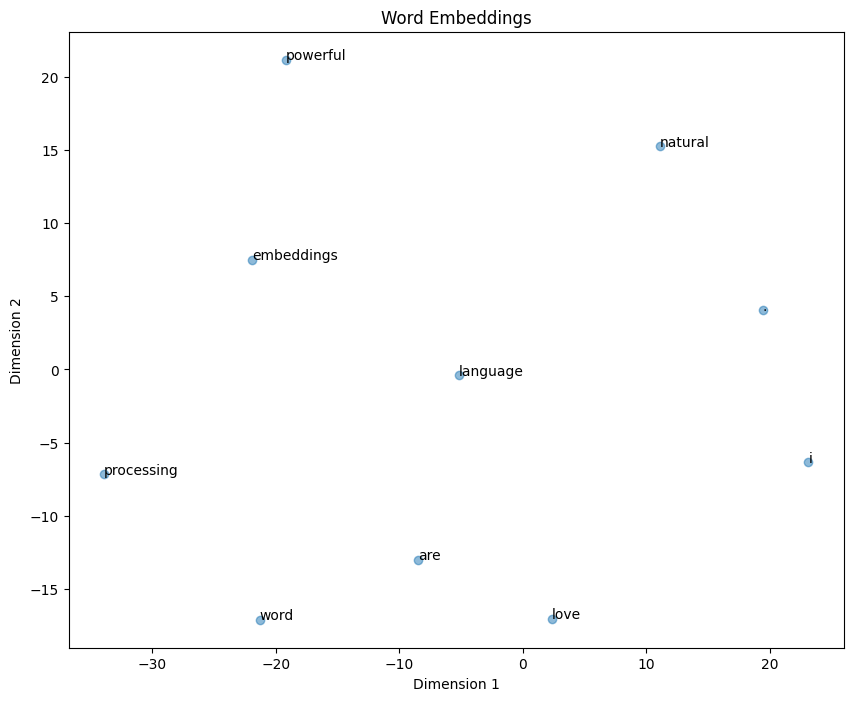

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import (
    TSNE,
)  # t-sochastic numerical embedding , pca format for numerical embeddings

# Get all word embeddings
# Retrieve all word embeddings from the Word2Vec model and store them in a list.
embeddings = [word_embeddings[word] for word in word_embeddings.index_to_key]

# Convert embeddings to numpy array
# Convert the list of word embeddings into a numpy array for compatibility with t-SNE.
embeddings_array = np.array(embeddings)

# Set perplexity
# Set the perplexity value for t-SNE. Perplexity is a hyperparameter that balances global and local aspects of the data.
# Here, we set it to the minimum of 5 or the number of embeddings to ensure it's within a reasonable range.
perplexity = min(
    5, len(embeddings)
)  # hyperparameter to make balance between local and global context

# Apply t-SNE to reduce dimensionality to 2D
# Initialize and apply t-SNE to reduce the dimensionality of the word embeddings to 2D for visualization.
tsne_model = TSNE(n_components=2, perplexity=perplexity, random_state=42)
embeddings_2d = tsne_model.fit_transform(embeddings_array)

# Plot the embeddings
# Create a scatter plot to visualize the 2D embeddings.
plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.5)

# Annotate each point with the corresponding word
# Add labels for each point in the scatter plot to indicate the corresponding word.
for i, word in enumerate(word_embeddings.index_to_key):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

# Add title and axis labels
# Set title and axis labels for the scatter plot.
plt.title("Word Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

# Show the plot
# Display the scatter plot.
plt.show()

This line imports the gensim.downloader module from the Gensim library. This module provides functions to download pre-trained models and datasets.

The code below downloads and loads the pre-trained GloVe word embeddings model named "glove-wiki-gigaword-100". The embeddings are loaded into the glove_model variable.

Similarly it downloads and loads the pre-trained Word2Vec word embeddings model named "word2vec-google-news-300". The embeddings are loaded into the word2vec_model variable.

This block defines a list of analogies. Each analogy is represented as a tuple containing three words: word1, word2, and word3. These analogies represent semantic relationships like "king is to man as queen is to woman".


This block evaluates analogies using the GloVe model:
It prints a header indicating that the following analogies are evaluated using GloVe embeddings.

It iterates over each analogy in the analogies list.
For each analogy, it extracts the three words (word1, word2, and word3).

It uses the most_similar() method of the glove_model to find the word that best completes the analogy.
It prints the analogy and the predicted word.


analogy
relationship between two words
4 words
3 words -> predict word

(king is to man is to woman)
glove / word2vec
king - man + woman
= we1 tries to resonate a queen
queen


In [1]:
import gensim.downloader as api

# Download and load GloVe embeddings
glove_model = api.load("glove-wiki-gigaword-100")  # pretrained models

# Download and load Word2Vec embeddings
word2vec_model = api.load("word2vec-google-news-300")
# Define analogies king is to man then queen is to ----------
analogies = [
    ("king", "man", "queen"),  # king - man + woman = queen
    ("man", "doctor", "woman"),  # man - doctor + nurse = woman
    ("paris", "france", "rome"),  # paris - france + italy = rome
    ("dog", "puppy", "cat"),  # dog - puppy + kitten = cat
]


# Evaluate analogies using GloVe
print("GloVe Analogies:")
# "king", "man", "queen
# w1  w2  w3


# queen - woman = king-man =>  queen =king-man+woman => queen -king +man = woman
# numerical embedding of woman
# glove model it will search for this valu and then key will be retrieved
# w1 w2 and w3

for analogy in analogies:
    word1, word2, word3 = analogy
    predicted_word = glove_model.most_similar(
        positive=[word2, word3], negative=[word1]
    )[0][0]
    print(f"{word1} is to {word2} as {word3} is to ")
    print(predicted_word)

# Evaluate analogies using Word2Vec
print("\nWord2Vec Analogies:")
for analogy in analogies:
    word1, word2, word3 = analogy
    predicted_word = word2vec_model.most_similar(
        positive=[word2, word3], negative=[word1]
    )[0][0]
    print(f"{word1} is to {word2} as {word3} is to {predicted_word}")

GloVe Analogies:
king is to man as queen is to 
woman
man is to doctor as woman is to 
nurse
paris is to france as rome is to 
italy
dog is to puppy as cat is to 
puppies

Word2Vec Analogies:
king is to man as queen is to woman
man is to doctor as woman is to gynecologist
paris is to france as rome is to italy
dog is to puppy as cat is to kitten


Download GloVe pretrained embeddings
For example, from https://nlp.stanford.edu/projects/glove/ download glove.6B.zip, unzip it, and keep glove.6B.100d.txt in your working folder.

Install gensim and nltk (if you haven’t already)


The glove-python library is:

❌ Old and unmaintained

❌ Difficult to install on Windows (requires Cython, a C++ compiler, and proper environment setup)

❌ Fails on runtime due to missing .pyd (compiled binary/DLL)

In [5]:
# Step 1: Download glove.6B.zip using curl (with HTTPS)
!curl -L -o glove.6B.zip https://nlp.stanford.edu/data/glove.6B.zip

# Step 2: Unzip using Python's built-in zipfile module
import zipfile

with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
    zip_ref.extractall(".")

# Step 3: Check if glove.6B.100d.txt exists using Python
import os

print("File exists:", os.path.isfile("glove.6B.100d.txt"))

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0
  0   346    0     0    0     0      0      0 --:--:--  0:00:02 --:--:--     0

  0     0    0     0    0     0      0      0 --:--:--  0:00:03 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:04 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:05 --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:06 --:--:--     0
  0  822M    0 65272    0     0   9218      0 25:58:52  0:00:07 25:58:45 16591
  0  822M    0  783k    0     0  99619      0  2:24:14  0:00:08  2:24:06  159k
  0  822M    0 2015k    0     0   223k      0  1:0

File exists: True


This code converts pre-trained GloVe word embeddings into the Word2Vec format so they can be easily loaded and used with the Gensim library. It first imports the necessary functions, then converts the GloVe file (glove.6B.100d.txt) into a Word2Vec-compatible file, and finally loads this converted file into a Gensim KeyedVectors model for further use like finding word similarities or vector operations.

In [6]:
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize

# Convert GloVe format to Word2Vec format
glove_input_file = "glove.6B.100d.txt"
word2vec_output_file = "glove.6B.100d.word2vec.txt"
glove2word2vec(glove_input_file, word2vec_output_file)

# Load model
model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

C:\Users\Tanisha Medewala\AppData\Local\Temp\ipykernel_17664\390253669.py:8: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


In [7]:
# Your toy dataset
sentences = [
    "Word embeddings capture semantic meanings.",
    "GloVe is an impactful word embedding model.",
]

# Tokenize and lowercase
tokenized_sentences = [word_tokenize(sentence.lower()) for sentence in sentences]

# Example: Get word vector and similarity
for sentence in tokenized_sentences:
    for word in sentence:
        if word in model:
            print(
                f"Embedding for '{word}': {model[word][:5]}"
            )  # printing first 5 dimensions
        else:
            print(f"'{word}' not in vocabulary")

# Most similar words
print(model.most_similar("embedding"))

Embedding for 'word': [ 0.1233   0.55741  0.74203 -0.06547 -0.33485]
Embedding for 'embeddings': [ 0.73248   0.37347   0.018861  0.54802  -0.1557  ]
Embedding for 'capture': [-0.46709 -0.59401  0.29404  0.23547  0.95611]
Embedding for 'semantic': [-0.18419  0.61556 -0.61709  0.61424  0.11026]
Embedding for 'meanings': [ 0.34531    0.69524   -0.0051361  0.26597    0.52593  ]
Embedding for '.': [-0.33979  0.20941  0.46348 -0.64792 -0.38377]
Embedding for 'glove': [ 0.3678   0.37074  0.32296 -0.43079 -0.14455]
Embedding for 'is': [-0.54264  0.41476  1.0322  -0.40244  0.46691]
Embedding for 'an': [-0.4214  -0.18797  0.46241 -0.17605  0.36212]
Embedding for 'impactful': [-0.018601   0.14764   -0.36943   -0.0040674 -0.23455  ]
Embedding for 'word': [ 0.1233   0.55741  0.74203 -0.06547 -0.33485]
Embedding for 'embedding': [-0.20802   0.091643 -0.22371   0.59371   0.46189 ]
Embedding for 'model': [-0.27663  0.55094  0.13618  0.59683 -0.24868]
Embedding for '.': [-0.33979  0.20941  0.46348 -0.6

c:\Users\Tanisha Medewala\AnacondaInstallation\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


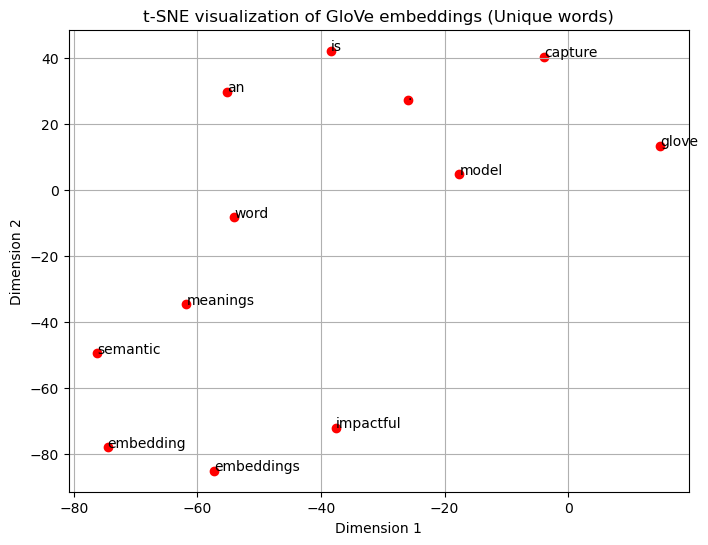

In [9]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

# Collect unique words and their vectors from the tokenized sentences
words = []
vectors = []
seen = set()

for sentence in tokenized_sentences:
    for word in sentence:
        if word in model and word not in seen:
            seen.add(word)
            words.append(word)
            vectors.append(model[word])

vectors = np.array(vectors)

# Run t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=5, n_iter=1000)
vectors_2d = tsne.fit_transform(vectors)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color="red")

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

plt.title("t-SNE visualization of GloVe embeddings (Unique words)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()